# 🚜 Predicting Bulldozer Sale Prices with fastai – A Tabular Regression Study

## Objective

This notebook explores the **Blue Book for Bulldozers** dataset from a real-world Kaggle regression competition. The goal is to **predict the sale prices of used bulldozers**, given structured tabular data that includes machine specifications, usage time, and sale dates.

We focus on the **use of fastai’s Tabular API** for structured data modeling. Throughout the process, we:

- Leverage **data preprocessing best practices** (missing value imputation, categorification, time-aware splits)
- Explore **tree-based models**: decision trees and random forests
- Train and compare a **neural network** on tabular features
- Investigate **model interpretation** tools (feature importance, partial dependence, etc.)
- Analyze **feature engineering effects** on RMSE performance
- Highlight **extrapolation limitations** and motivation for model ensemble

> ✅ This notebook demonstrates a professional-level deep learning workflow on structured data, bridging fastai’s convenience with rigorous model interpretation and classical ML comparison.



# Dataset: bluebook-for-bulldozers
[Blue Book for Bulldozers – Kaggle](https://www.kaggle.com/competitions/bluebook-for-bulldozers) 

In [1]:
#from pandas.api.types import is_string_dtype, is_numeric_dtype, is_categorical_dtype
from fastai.tabular.all import *
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from dtreeviz.trees import *
pd.options.display.max_rows = 20
pd.options.display.max_columns = 8
import warnings
warnings.filterwarnings('ignore')

## Download via kaggle

In [ ]:
creds = '{"username":"apple9855wang","key":"dd64a714207b1ee44d4da89abb2e0366"}'

In [ ]:
cred_path = Path('~/.kaggle/kaggle.json').expanduser()
if not cred_path.exists():
    cred_path.parent.mkdir(exist_ok=True)
    cred_path.write_text(creds)
    cred_path.chmod(0o600)

In [ ]:
from kaggle import api
! kaggle competitions download -c bluebook-for-bulldozers
if not path.exists():
    path.mkdir(parents=true)
    file_extract(path/'bluebook-for-bulldozers.zip')

## Manully download in local

In [2]:
path = Path("/Users/applewang//Desktop/Study_Materials_2023_2025/fastai_course/my-practice/bluebook-for-bulldozers")
Path.BASE_PATH = path

In [3]:
path.ls(file_type='text')

(#7) [Path('random_forest_benchmark_test.csv'),Path('Valid.csv'),Path('median_benchmark.csv'),Path('Test.csv'),Path('ValidSolution.csv'),Path('Machine_Appendix.csv'),Path('TrainAndValid.csv')]

## Preprocessing

In [4]:
df = pd.read_csv(path/'TrainAndValid.csv', low_memory=False)
df.head(2)

,SalesID,SalePrice,MachineID,ModelID,...,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls
0,1139246,66000.0,999089,3157,...,NaN,NaN,Standard,Conventional
1,1139248,57000.0,117657,77,...,NaN,NaN,Standard,Conventional


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412698 entries, 0 to 412697
Data columns (total 53 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   SalesID                   412698 non-null  int64  
 1   SalePrice                 412698 non-null  float64
 2   MachineID                 412698 non-null  int64  
 3   ModelID                   412698 non-null  int64  
 4   datasource                412698 non-null  int64  
 5   auctioneerID              392562 non-null  float64
 6   YearMade                  412698 non-null  int64  
 7   MachineHoursCurrentMeter  147504 non-null  float64
 8   UsageBand                 73670 non-null   object 
 9   saledate                  412698 non-null  object 
 10  fiModelDesc               412698 non-null  object 
 11  fiBaseModel               412698 non-null  object 
 12  fiSecondaryDesc           271971 non-null  object 
 13  fiModelSeries             58667 non-null   o

### `add_datepart` function
transform the `saledate` into: 'saleYear', 'saleMonth',
       'saleWeek', 'saleDay', 'saleDayofweek', 'saleDayofyear',
       'saleIs_month_end', 'saleIs_month_start', 'saleIs_quarter_end',
       'saleIs_quarter_start', 'saleIs_year_end', 'saleIs_year_start',
       'saleElapsed'

In [7]:
df = add_datepart(df,'saledate')

In [8]:
len(df.columns)

65

In [9]:
df['ProductSize'].unique()

array([nan, 'Medium', 'Small', 'Large / Medium', 'Mini', 'Large',
       'Compact'], dtype=object)

In [10]:
sizes = 'Large','Large / Medium','Medium','Small','Mini','Compact'
df['ProductSize'] = df['ProductSize'].astype('category')
df['ProductSize'] = df['ProductSize'].cat.set_categories(sizes, ordered=True)

In [11]:
dep_var = 'SalePrice'
df[dep_var] = np.log1p(df[dep_var])

### TabularPandas and TabularProc

To handle categorical variables and missing values, we use **`TabularPandas`** from fastai, which simplifies tabular preprocessing.

- `Categorify`: Converts string categories to numeric codes
- `FillMissing`: Replaces missing values with median and adds indicator columns

These `TabularProc`s modify the dataframe in-place and are standard starting points for structured data processing.

### Time-Based Data Split for Bulldozers Dataset

To simulate real-world deployment and avoid data leakage, we split the training and validation sets **based on time**:

- **Training set**: Data before **November 2011**
- **Validation set**: Data from **November 2011 to April 2012**

This reflects the temporal nature of the competition: predicting future sale prices based on past patterns.

> ⚠️ **Note**: Time-based splitting can lead to **distribution shift**, where the validation set may follow a different distribution than the training data. This makes the task more realistic but also more challenging.

In [ ]:
procs = [Categorify, FillMissing]

condition = (df.saleYear<2011) | (df.saleMonth<10) 
train_idx = np.where(condition)[0]
valid_idx = np.where(~condition)[0]

splits = (list(train_idx),list(valid_idx))

cont, cat = cont_cat_split(df, max_card=1, dep_var=dep_var)

to = TabularPandas(df, procs, cat, cont, y_names=dep_var, splits=splits)

In [17]:
len(to.train), len(to.valid)

(404710, 7988)

In [18]:
to.show(2)

,UsageBand,fiModelDesc,fiBaseModel,fiSecondaryDesc,fiModelSeries,fiModelDescriptor,ProductSize,fiProductClassDesc,state,ProductGroup,ProductGroupDesc,Drive_System,Enclosure,Forks,Pad_Type,Ride_Control,Stick,Transmission,Turbocharged,Blade_Extension,Blade_Width,Enclosure_Type,Engine_Horsepower,Hydraulics,Pushblock,Ripper,Scarifier,Tip_Control,Tire_Size,Coupler,Coupler_System,Grouser_Tracks,Hydraulics_Flow,Track_Type,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls,saleIs_month_end,saleIs_month_start,saleIs_quarter_end,saleIs_quarter_start,saleIs_year_end,saleIs_year_start,auctioneerID_na,MachineHoursCurrentMeter_na,SalesID,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,saleYear,saleMonth,saleWeek,saleDay,saleDayofweek,saleDayofyear,saleElapsed,SalePrice
0,Low,521D,521,D,#na#,#na#,#na#,Wheel Loader - 110.0 to 120.0 Horsepower,Alabama,WL,Wheel Loader,#na#,EROPS w AC,None or Unspecified,#na#,None or Unspecified,#na#,#na#,#na#,#na#,#na#,#na#,#na#,2 Valve,#na#,#na#,#na#,#na#,None or Unspecified,None or Unspecified,#na#,#na#,#na#,#na#,#na#,#na#,#na#,#na#,#na#,#na#,#na#,#na#,Standard,Conventional,False,False,False,False,False,False,False,False,1139246,999089,3157,121,3.0,2004,68.0,2006,11,46,16,3,320,1.163635e+09,11.097425
1,Low,950FII,950,F,II,#na#,Medium,Wheel Loader - 150.0 to 175.0 Horsepower,North Carolina,WL,Wheel Loader,#na#,EROPS w AC,None or Unspecified,#na#,None or Unspecified,#na#,#na#,#na#,#na#,#na#,#na#,#na#,2 Valve,#na#,#na#,#na#,#na#,23.5,None or Unspecified,#na#,#na#,#na#,#na#,#na#,#na#,#na#,#na#,#na#,#na#,#na#,#na#,Standard,Conventional,False,False,False,False,False,False,False,False,1139248,117657,77,121,3.0,1996,4640.0,2004,3,13,26,4,86,1.080259e+09,10.950824


# Tree-based Models
## Decision Trees

In [24]:
#save_pickle(path/'t.pkl',t) 
#to = load_pickle(path/'t.pkl')

In [19]:
xs,y = to.train.xs, to.train.y
valid_xs, valid_y = to.valid.xs, to.valid.y

In [20]:
m = DecisionTreeRegressor(max_leaf_nodes=4)
m.fit(xs, y)

DecisionTreeRegressor(max_leaf_nodes=4)

(`draw_tree` from fastbook API)

In [21]:
from sklearn.tree import export_graphviz

def draw_tree(t, df, size=10, ratio=0.6, precision=0, **kwargs):
    s=export_graphviz(t, out_file=None, feature_names=df.columns, filled=True, rounded=True,
                      special_characters=True, rotate=False, precision=precision, **kwargs)
    return graphviz.Source(re.sub('Tree {', f'Tree {{ size={size}; ratio={ratio}', s))

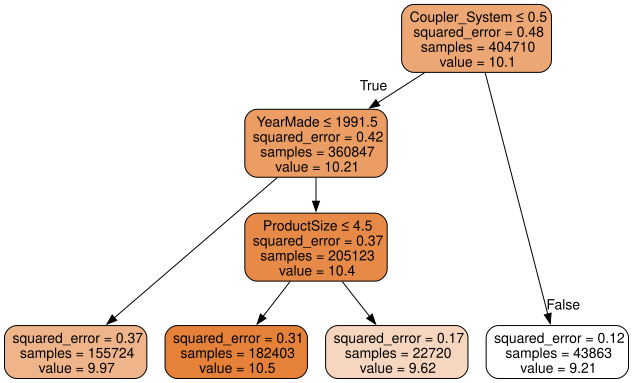

In [22]:
draw_tree(m, xs, size=10, leaves_parallel=True, precision=2)

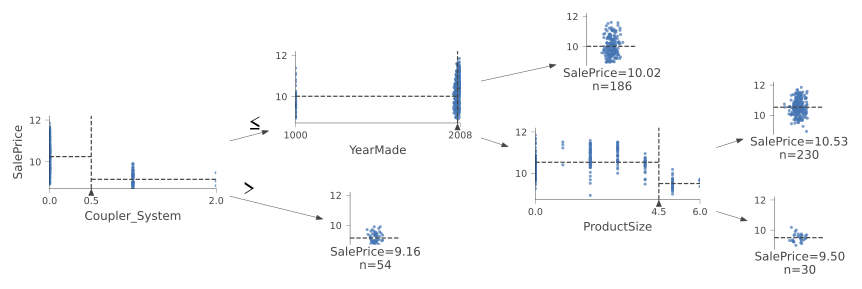

In [23]:
samp_idx = np.random.permutation(len(y))[:500]
dtreeviz(m, xs.iloc[samp_idx], y.iloc[samp_idx], xs.columns, dep_var,
        fontname='DejaVu Sans', scale=1.6, label_fontsize=10,
        orientation='LR')

In [24]:
#Some YearMade=1000 - not reasonable -> change to 1950 may more reasonable.
xs.loc[xs['YearMade']<1900, 'YearMade'] = 1950
valid_xs.loc[valid_xs['YearMade']<1900, 'YearMade'] = 1950

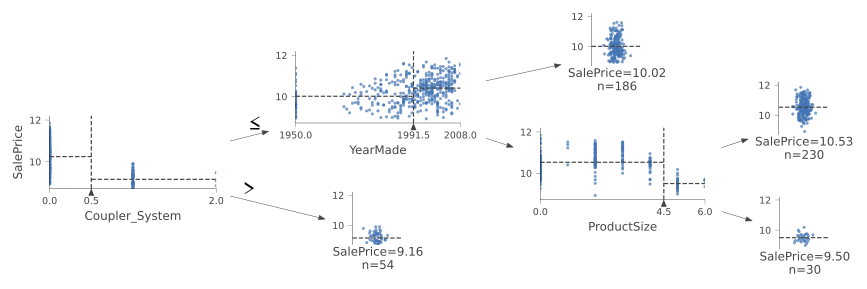

In [25]:
m = DecisionTreeRegressor(max_leaf_nodes=4).fit(xs, y)

dtreeviz(m, xs.iloc[samp_idx], y.iloc[samp_idx], xs.columns, dep_var,
        fontname='DejaVu Sans', scale=1.6, label_fontsize=10,
        orientation='LR')

### RMSE Metrics

In [30]:
# train rmse
def r_mse(pred,y): return round(math.sqrt(((pred-y)**2).mean()), 6)
# model predictions rmse
def m_rmse(m, xs, y): return r_mse(m.predict(xs), y)

if no `max_leaf_nodes` here, it will create too many leaves! it will probably result in overfitting!

In [31]:
m = DecisionTreeRegressor() #create a tree with on limitation...
m.fit(xs,y)

DecisionTreeRegressor()

In [32]:
m_rmse(m, xs, y),m_rmse(m, valid_xs, valid_y) #clearly overfitting

(0.0, 0.334711)

In [33]:
m.get_n_leaves(), len(xs) #too much leaves, close to sample nums

(324565, 404710)

In [34]:
m = DecisionTreeRegressor(min_samples_leaf=25) #每个叶节点至少包含25个样本
m.fit(xs, y)
m_rmse(m, xs, y),m_rmse(m, valid_xs, valid_y)

(0.211695, 0.268746)

In [35]:
m.get_n_leaves()

12400

## Random Forests - oob_score

Random Forest is an ensemble learning method that builds multiple decision trees and aggregates their predictions for improved accuracy and robustness. Key techniques and hyperparameters include:

### Core Ideas
- **Bagging (Bootstrap Aggregating)**:  
  - Train multiple trees on **random subsets** of the data (with replacement).  
  - Aggregation (averaging or majority vote) reduces variance and helps smooth out noisy predictions.
- **OOB (Out-of-Bag) Estimation**:  
  - Each tree uses a bootstrap sample (~63% of data). The remaining ~37% ("out-of-bag" data) can serve as a **validation set** for estimating generalization performance without needing a separate split.
  - Use `oob_score=True` to enable this. Later accessible via `model.oob_score_`.

### Common Hyperparameters
| Parameter | Description |
|-----------|-------------|
| `max_samples` | Number or fraction of samples to draw for each tree (default: all) |
| `min_samples_leaf` | Minimum number of samples required to be at a leaf node (regularizes tree depth) |
| `max_features` | Number of features considered when splitting each node. Common values: `"sqrt"` (default for classification), `"log2"`, or `None` (all features) |

> ⚠️ Tip: Random Forests handle tabular data well, especially when feature interactions are complex and nonlinear. They are also **robust to overfitting** and require little feature engineering.

In [36]:
def rf(xs, y, n_estimators=40, max_samples=200_000, 
       min_samples_leaf=5, max_features=0.5, **kwargs):
    return RandomForestRegressor(n_estimators=n_estimators, n_jobs=-1, 
                                 max_samples=max_samples, 
                                 min_samples_leaf=min_samples_leaf,
                                max_features=max_features,oob_score=True).fit(xs,y)

In [37]:
m = rf(xs,y)
m_rmse(m, xs, y),m_rmse(m, valid_xs, valid_y)

(0.171144, 0.233451)

Here average 40 trees caused a lot overfitting.

In [38]:
r_mse(m.oob_prediction_,y) #Prediction computed with out-of-bag estimate on the training set. 

0.210918

### OOB Score vs. Validation RMSE

If the **Out-of-Bag (OOB) score** appears significantly **better than the validation set performance** (e.g., lower RMSE on validation), this may indicate one or more of the following:

1. **Overfitting to Training Data**  
   The model may overfit to patterns in the bootstrap samples, performing well on OOB samples (which still come from training distribution), but poorly on the held-out validation set.

2. **Distribution Shift between OOB and Validation Sets**  
   The OOB samples are drawn from the same original dataset, while the validation set might come from a different time period or subpopulation (as in time-based splits), leading to degraded generalization.

3. **Model Bias toward Certain Data Subsets**  
   The model might perform disproportionately well on certain feature combinations prevalent in OOB samples but underrepresented in the validation set.

> 🔍 Always validate model assumptions against actual data splits — OOB estimates are helpful, but not a replacement for a robust validation set.

# Model Interpretation (Tabular)

In tabular tasks, interpretability is crucial for trust and actionability. Key questions I explore:

- How confident is the prediction?
- Which features drove this prediction?
- Which features matter most overall?
- Are any features redundant or weak?
- How does prediction shift with feature changes?

> Interpretation bridges the gap between performance and explainability in real-world ML.

## Prediction Confidence
Tree variance for predict confidence

In [39]:
#tree variances of rf model
preds = np.stack([t.predict(valid_xs) for t in m.estimators_]) #rf set 40 n_estimators

In [40]:
preds.std(0)[:10]

array([0.23661989, 0.10111261, 0.12436234, 0.27283797, 0.12165818,
       0.25841754, 0.33368917, 0.33203955, 0.26020223, 0.20345435])

Each tree variance spread widely...might lead out low confidence, the predicted aution price may vary each time.

## Feature Importance
- to examine whether some features can be ignored?
- `model.feature_importances_` identify major drivers.

In [41]:
def rf_feat_importance(df, m):
    return pd.DataFrame({'col':df.columns, 'imp': m.feature_importances_}).sort_values('imp', ascending=False)

In [42]:
fi = rf_feat_importance(xs, m)
fi[:10]

,col,imp
57,YearMade,0.184640
30,Coupler_System,0.128589
6,ProductSize,0.124413
7,fiProductClassDesc,0.071976
54,ModelID,0.051361
65,saleElapsed,0.051079
3,fiSecondaryDesc,0.041034
31,Grouser_Tracks,0.037495
1,fiModelDesc,0.032529
32,Hydraulics_Flow,0.026647


In [43]:
def plot_fi(fi):
    return fi.plot('col','imp','barh', figsize=(8,6), legend=False)

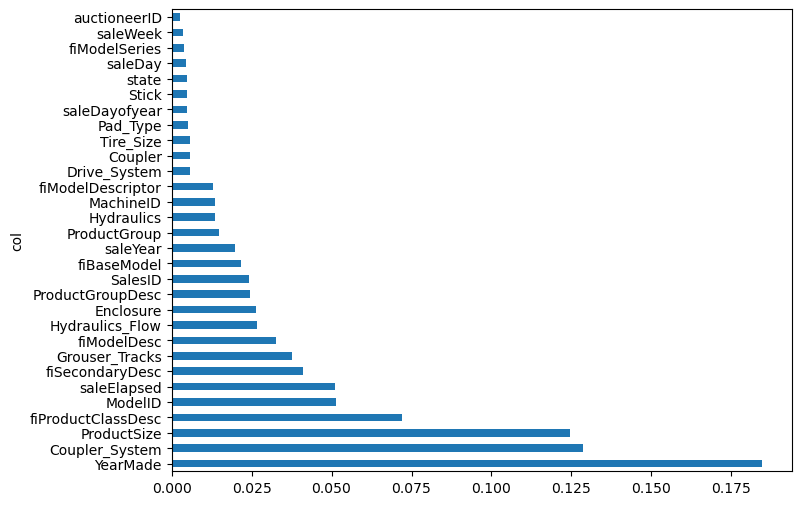

In [44]:
plot_fi(fi[:30]);

## Feature Selection
Drop low-importance features to simplify model

In [97]:
len(fi.col)

66

In [98]:
to_keep = fi[fi.imp>0.005].col

In [99]:
len(to_keep)

22

In [100]:
xs_imp = xs[to_keep]
valid_xs_imp = valid_xs[to_keep]

In [101]:
m = rf(xs_imp, y)
m_rmse(m, xs_imp,y), m_rmse(m, valid_xs_imp,valid_y)

(0.180945, 0.23215)

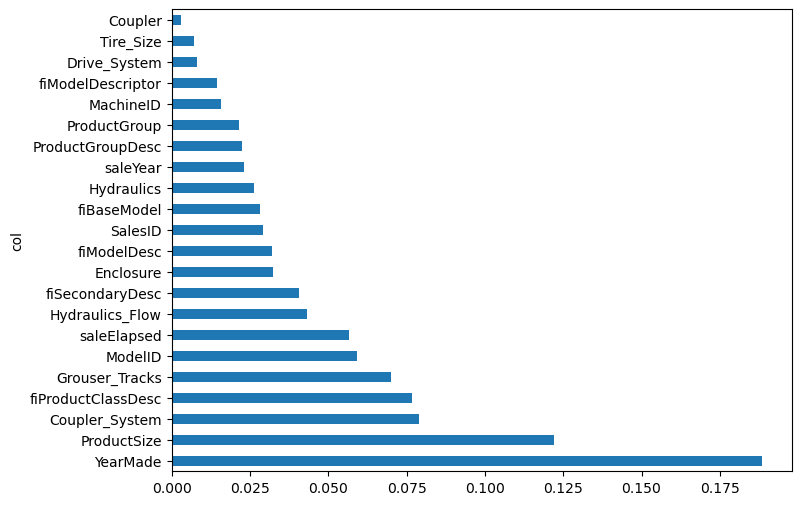

In [102]:
plot_fi(rf_feat_importance(xs_imp,m));

some features are redundant

In [103]:
from scipy.cluster import hierarchy as hc

def cluster_columns(df, figsize=(8,6), font_size=8):
    corr = np.round(scipy.stats.spearmanr(df).correlation, 4)
    corr_condensed = hc.distance.squareform(1-corr)
    z = hc.linkage(corr_condensed, method='average')
    fig = plt.figure(figsize=figsize)
    hc.dendrogram(z, labels=df.columns, orientation='left', leaf_font_size=font_size)
    plt.show()

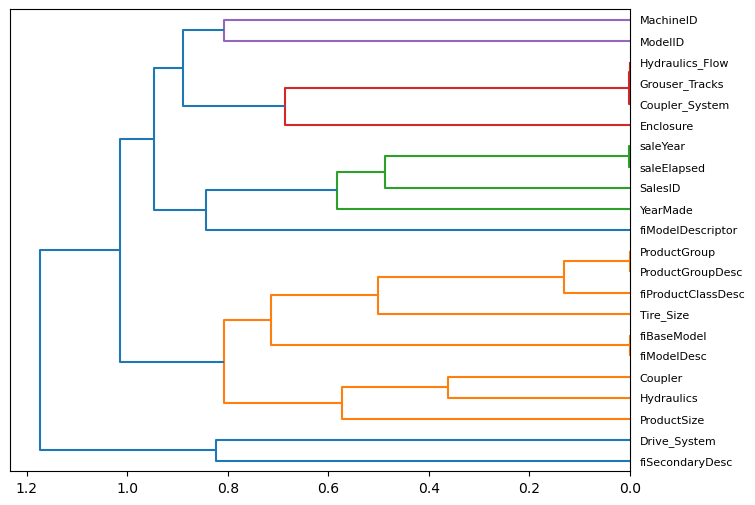

In [104]:
cluster_columns(xs_imp)

In [105]:
def get_oob(df):
    m = RandomForestRegressor(n_estimators=40, min_samples_leaf=20,
        max_samples=50000, max_features=0.5, n_jobs=-1, oob_score=True)
    m.fit(df, y)
    return round(m.oob_score_,6)

In [106]:
get_oob(xs_imp) #baseline

0.871494

In [107]:
#check OOB if remove some features
{c:get_oob(xs_imp.drop(c, axis=1)) for c in (
    'saleYear', 'saleElapsed', 'ProductGroupDesc','ProductGroup',
    'fiModelDesc', 'fiBaseModel',
    'Hydraulics_Flow','Grouser_Tracks', 'Coupler_System','Coupler', 'Hydraulics', 'fiSecondaryDesc')}

{'saleYear': 0.87037,
 'saleElapsed': 0.866907,
 'ProductGroupDesc': 0.872529,
 'ProductGroup': 0.871295,
 'fiModelDesc': 0.869587,
 'fiBaseModel': 0.870572,
 'Hydraulics_Flow': 0.871811,
 'Grouser_Tracks': 0.872005,
 'Coupler_System': 0.87141,
 'Coupler': 0.87175,
 'Hydraulics': 0.871628,
 'fiSecondaryDesc': 0.867625}

In [112]:
to_drop = ['ProductGroupDesc','Hydraulics_Flow','Grouser_Tracks','Coupler']
get_oob(xs_imp.drop(to_drop, axis=1))

0.871726

In [113]:
xs_final = xs_imp.drop(to_drop, axis=1)
valid_xs_final = valid_xs_imp.drop(to_drop, axis=1)
#save_pickle(path/'xs_final.pkl', xs_final)
#save_pickle(path/'valid_xs_final.pkl', valid_xs_final)
#xs_final = load_pickle(path/'xs_final.pkl')
#valid_xs_final = load_pickle(path/'valid_xs_final.pkl')

In [114]:
len(xs_final.columns) #xs_imp has 22 features

18

In [115]:
m_final = rf(xs_final, y)
m_rmse(m_final,xs_final, y), m_rmse(m_final, valid_xs_final, valid_y)

(0.180709, 0.231264)

## Partial Dependence Analysis
Visualize feature effect on predictions

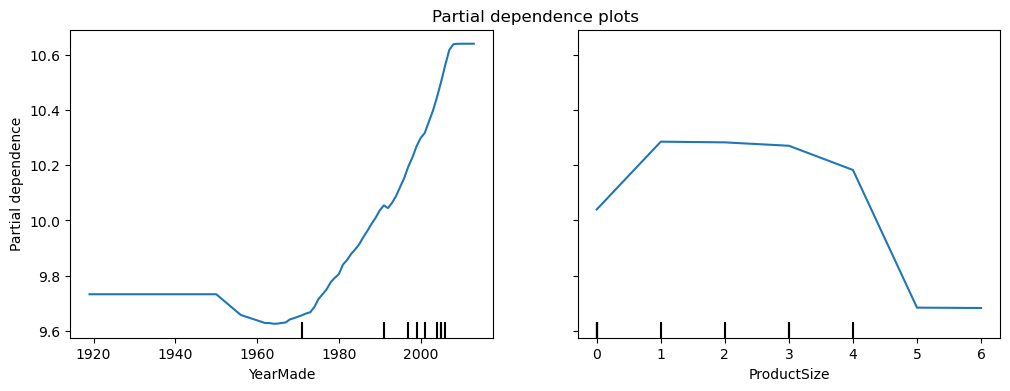

In [116]:
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(12, 4))
ax.set_title("Partial dependence plots")
display=PartialDependenceDisplay.from_estimator(m_final, valid_xs_final, ['YearMade','ProductSize'],ax=ax)

Partial Dependence Plots (PDP) show the effect of a feature on model predictions, marginalizing over other variables. Helpful for understanding non-linear interactions and saturation effects.

- `YearMade`: A clear upward trend — newer equipment tends to fetch higher prices. This aligns with the concept of depreciation: value increases with more recent manufacture dates.

- `ProductSize`: Sharp drop-off at the highest category.


⚠️ Data Leakage Risk:
Missing values in ProductSize appear correlated with price. This suggests the pattern of missingness may carry predictive signal, potentially misleading the model.
    - Consider imputing or modeling the missingness explicitly.

## Data Leakage Check
- Identify suspicious features boosting accuracy: 
    - Check whether the accuracy of the model is too good to be true.
    - Look for important predictors that don't make sense in practice.
    - Look for partial dependence plot results that don't make sense in practice.

### Tree interpreter + waterfall_chart
- treeinterpreter -- calculate "contributions" -- help to identify which features influence the specific predictions:
- `predictions = contributions (of features) + bias`
- waterfall -- visualize "contributions" -- identify the specific features from contributions

In [117]:
from treeinterpreter import treeinterpreter
from waterfall_chart import plot as waterfall

In [118]:
five_valids = valid_xs_final[:5]
predictions, bias, contributions = treeinterpreter.predict(m_final, five_valids.values)

In [119]:
#predictions = contributions + bias
predictions[0], bias[0], contributions[0].sum()

(array([9.98721415]), 10.104635888188241, -0.11742173791786101)

threshold=0.08 means factors>0.08 will be shown;

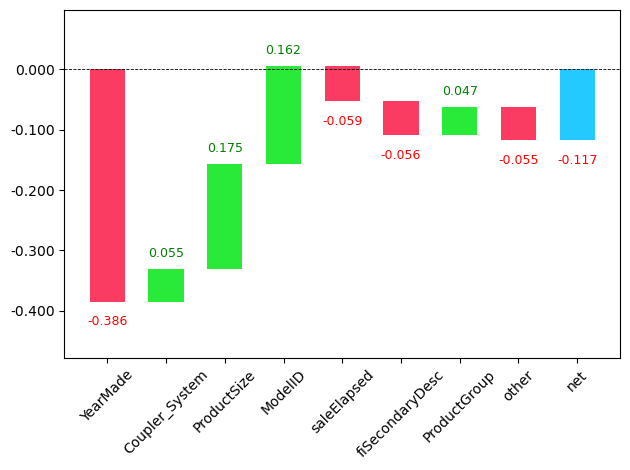

In [120]:
waterfall(valid_xs_final.columns, contributions[0], threshold=0.08, rotation_value=45, formatting='{:,.3f}'); 

This plot is more useful in production than model development; The specific prediction can be explained to your users.

# Extrapolation Challenge with Tree-Based Models

Tree-based models struggle with extrapolation — they can only predict within the range of training data.

This is because:
- Each tree makes decisions based on discrete splits from the training set
- The ensemble prediction is a weighted average of training-observed outcomes
    - As a result, out-of-range values or novel combinations cannot be effectively modeled.



In [107]:
np.random.seed(42)
x_lin = torch.linspace(0,20,steps=40)
y_lin = x_lin + torch.randn_like(x_lin)
xs_lin=x_lin.unsqueeze(1)

In [108]:
m_lin = RandomForestRegressor().fit(xs_lin[:30],y_lin[:30]) #only train first 30 datapoints, last 10 are unknown

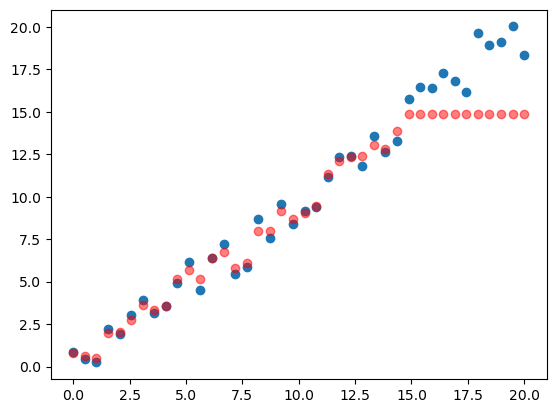

In [110]:
plt.scatter(x_lin, y_lin)
plt.scatter(x_lin, m_lin.predict(xs_lin),color='red', alpha=0.5);

Last 10 unseen data--prediction is poor here. So, we can use RF to identify what causes unseen features, affecting the poor performance. 
### Finding Out-of-domain Data
How to find that which feature will lead -> data leakage or unstable performance? 

In [132]:
#use rf to predict whether xs belongs to train or valid
df_dom = pd.concat([xs_final, valid_xs_final])
is_valid = np.array([0]*len(xs_final)+[1]*len(valid_xs_final))
m = rf(df_dom, is_valid)
rf_feat_importance(df_dom, m)[:6]

,col,imp
5,saleElapsed,0.622122
11,saleYear,0.294424
9,SalesID,0.079419
14,MachineID,0.002711
0,YearMade,0.000686
13,Hydraulics,0.000141


In [133]:
m = rf(xs_final, y)
print('orig', m_rmse(m, valid_xs_final, valid_y))

for c in ('saleElapsed','SalesID','MachineID','ModelID'):
    m = rf(xs_final.drop(c,axis=1), y)
    print(c, m_rmse(m, valid_xs_final.drop(c,axis=1), valid_y))

orig 0.231536
saleElapsed 0.230139
SalesID 0.22963
MachineID 0.229456
ModelID 0.234099


It shows that `SalesID` and `MachineID` will affect the accuracy (of predicting whether train or valid) more than `saleElapsed`. They lead the unstable situation \might increment over time. So, remove these two columns.

In [134]:
time_vars = ['SalesID','MachineID']
xs_final_time = xs_final.drop(time_vars, axis=1)
valid_xs_time = valid_xs_final.drop(time_vars, axis=1)

m = rf(xs_final_time, y)
m_rmse(m,xs_final_time, y) ,m_rmse(m, valid_xs_time, valid_y)

(0.188171, 0.229268)

It actually improves😁. 
- Previous: random forest (22 drop 4 redundant): (0.180709, **0.231264**)
- Now: drop 2 more features is better!

### Impact of Removing Early-Year Samples (Low-volume Periods)

To test whether the small number of samples before 2004 is hurting model performance, we retrain the model excluding all data before 2005.

Despite the increased sample size in later years, the performance shows only minor improvement, indicating that:
- The volume effect of early data is minimal
- The model generalization is still bottlenecked by feature quality, not just volume

This highlights the importance of careful feature engineering and model selection beyond naive temporal filtering.

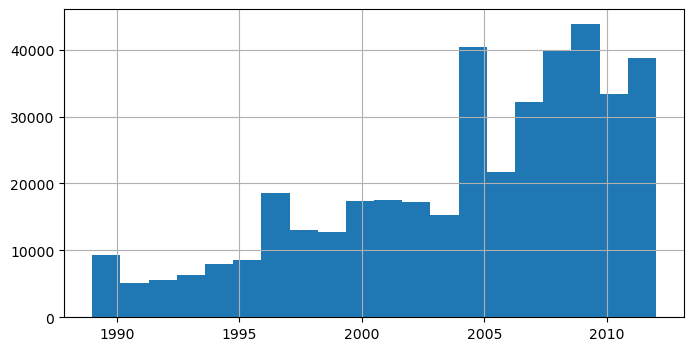

In [125]:
xs['saleYear'].hist(figsize=(8,4),bins=20);

In [135]:
filt = xs['saleYear']>2004
xs_filt = xs_final_time[filt]
y_filt = y[filt]
m=rf(xs_filt, y_filt)
m_rmse(m, xs_filt, y_filt), m_rmse(m, valid_xs_time, valid_y)

(0.173382, 0.228141)

# Comparison on Tree-Based Model (RMSE)

| Model Description                               | RMSE (Train) | RMSE (Valid) | Notes                          |
|--------------------------------------------------|--------------|--------------|--------------------------------|
| Decision Tree (overfitted, deep tree)           | 0.000        | 0.3347       | ❗️ Severe overfitting 🤔        |
| Decision Tree (max_samples=25)                  | 0.2117       | 0.2687       | ✅ Improved generalization |
| Random Forest (40 trees, all features)          | 0.1711       | 0.2335       | ✅ Better, but still overfitting |
| Random Forest (top 22 features)                 | 0.1809       | 0.2321       | ✅ Improved feature selection |
| Random Forest (22 - 4 redundant = 18 features)  | 0.1807       | 0.2313       | ✅ `xs_final` less features with similar RMSE |
| Random Forest (remove SaleID, MachineID)  | 0.1882       | 0.2293       | ✅ `xs_final_time` same          |
| Random Forest (only post-2005 data)             | 0.1734       | 0.2281       | ✅ `xs_filt` best so far |

> Motivation for Trying Neural Networks
> 
>To better handle continuous variables, generalize beyond the training domain, and capture complex patterns, we next explore neural network models, via `fastai.tabular_learner()`.

# Neural Network using Fastai
## Preprocess 

In [136]:
df_nn = pd.read_csv(path/"TrainAndValid.csv", low_memory=False)
df_nn['ProductSize']=df_nn['ProductSize'].astype('category')
df_nn['ProductSize'] = df_nn['ProductSize'].cat.set_categories(sizes, ordered=True)
df_nn[dep_var]=np.log(df_nn[dep_var])
df_nn = add_datepart(df_nn, 'saledate')

In [137]:
df_nn_final = df_nn[list(xs_final_time.columns)+ [dep_var]]
df_nn_final.columns

Index(['YearMade', 'Coupler_System', 'ProductSize', 'fiProductClassDesc',
       'ModelID', 'saleElapsed', 'fiSecondaryDesc', 'fiModelDesc', 'Enclosure',
       'fiBaseModel', 'saleYear', 'ProductGroup', 'Hydraulics',
       'fiModelDescriptor', 'Drive_System', 'Tire_Size', 'SalePrice'],
      dtype='object')

In [138]:
cont_nn, cat_nn = cont_cat_split(df_nn_final, max_card=9000, dep_var=dep_var)

In [140]:
df_nn_final[cat_nn].nunique()

YearMade                73
Coupler_System           2
ProductSize              6
fiProductClassDesc      74
ModelID               5281
fiSecondaryDesc        177
fiModelDesc           5059
Enclosure                6
fiBaseModel           1961
saleYear                24
ProductGroup             6
Hydraulics              12
fiModelDescriptor      140
Drive_System             4
Tire_Size               17
dtype: int64

In [141]:
xs_filt2 = xs_filt.drop('fiModelDesc', axis=1)
valid_xs_time2 = valid_xs_time.drop('fiModelDesc', axis=1)
m2 = rf(xs_filt2, y_filt)
m_rmse(m2, xs_filt2, y_filt), m_rmse(m2, valid_xs_time2, valid_y)

(0.175946, 0.229757)

In [142]:
cat_nn.remove('fiModelDesc')

In [143]:
procs_nn = [Categorify, FillMissing, Normalize]
to_nn = TabularPandas(df_nn_final, procs_nn, cat_nn, cont_nn, splits=splits, y_names=dep_var)
dls = to_nn.dataloaders(1024)

In [144]:
y = to_nn.train.y
y.min(), y.max()

(8.465899, 11.863583)

## Train & Predict

In [145]:
learn = tabular_learner(dls, y_range=(8,12), layers=[500,250],n_out=1, loss_func=F.mse_loss)

SuggestedLRs(valley=0.00015848931798245758)

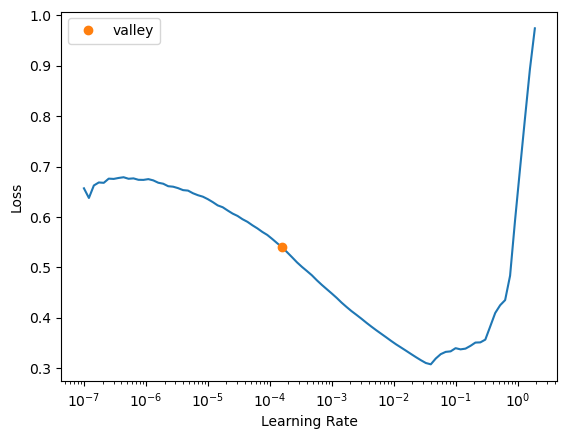

In [146]:
learn.lr_find()

In [147]:
learn.fit_one_cycle(5, 0.01)

epoch,train_loss,valid_loss,time
0,0.061012,0.073757,00:03
1,0.054827,0.065217,00:03
2,0.048071,0.057090,00:03
3,0.042407,0.052667,00:03
4,0.040089,0.050281,00:03


In [148]:
preds, targs = learn.get_preds()

In [149]:
r_mse(preds, targs)

0.224235

Better than best random forest model.

In [170]:
#learn.save('nn')

## Ensemble RF + NN
Ensemble the rf predictions & nn predictions can also improve performance.

In [150]:
#ensemble the rf predictions & nn predictions
rf_preds = m.predict(valid_xs_time)
nn_preds = to_np(preds.squeeze())
en_preds = (rf_preds+nn_preds)/2

In [151]:
r_mse(en_preds, valid_y)

0.220427

# Final Model RMSE Comparison

| Model                       | RMSE        | Notes                                  |
|----------------------------|-------------|----------------------------------------|
| Random Forest (tuned)      | **0.2281**  | After feature selection & filtering    |
| Neural Net (fastai)        | **0.2242**  | Trained with Tabular Learner           |
| Ensemble (RF + NN avg)     | **0.2204**  | Simple average of two predictions      |

# 🎯 Conclusion: Modeling Strategy & Key Insights

This project tackled a real-world tabular regression task using both classical machine learning and deep learning approaches, emphasizing model interpretability, time-aware validation, and practical framework usage.

- ✅ **Tree-based models (Random Forest)** offered strong baseline performance (**rMSE ≈ 0.228**) with excellent interpretability and low training cost.
- ✅ **Tabular Neural Networks** (via fastai `TabularLearner`) slightly outperformed RF (**rMSE ≈ 0.224**), benefiting from entity embeddings and regularization.
- ✅ **Hybrid ensemble (RF + NN)** further improved predictive performance (**rMSE ≈ 0.220**), highlighting the complementary strengths of model classes.

**Modeling Highlights**:
- Used **fastai Tabular API** to simplify preprocessing, categorical embedding, and training loops.
- Applied **time-based validation splits** to better simulate real-world generalization scenarios.
- Conducted **progressive model interpretation**, including:
  - Feature importance ranking
  - Partial dependence plots
  - Analysis of extrapolation boundaries

> This notebook reflects practical ML/DL decision-making: balancing model complexity, interpretability, and performance — essential skills for any deep learning engineer working with structured data.